In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/13_Linear_regression/Advertising.csv')

In [4]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
X = df.drop('sales',axis=1)
y = df['sales']

# Polynomial Regression

In [6]:
from sklearn.preprocessing import PolynomialFeatures

In [7]:
polynomial_converter = PolynomialFeatures(degree=3,include_bias=False)

In [8]:
#polynomial_converter.fit(X)

In [9]:
#polynomial_converter.transform(X)

In [10]:
poly_features = polynomial_converter.fit_transform(X)

In [11]:
poly_features.shape

(200, 19)

In [12]:
X.shape

(200, 3)

In [13]:
X.iloc[0]

,0
TV,230.1
radio,37.8
newspaper,69.2


In [14]:
poly_features[0]

array([2.30100000e+02, 3.78000000e+01, 6.92000000e+01, 5.29460100e+04,
       8.69778000e+03, 1.59229200e+04, 1.42884000e+03, 2.61576000e+03,
       4.78864000e+03, 1.21828769e+07, 2.00135918e+06, 3.66386389e+06,
       3.28776084e+05, 6.01886376e+05, 1.10186606e+06, 5.40101520e+04,
       9.88757280e+04, 1.81010592e+05, 3.31373888e+05])

In [15]:
poly_features[0][:3]

array([230.1,  37.8,  69.2])

In [16]:
poly_features[0][:3]**2

array([52946.01,  1428.84,  4788.64])

In [17]:
230.1*37.8

8697.779999999999

In [18]:
230.1*69.2

15922.92

In [19]:
37.8*69.2

2615.7599999999998

## Train|Test Split

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(poly_features,y,test_size=0.3,random_state=101)

# Model for fitting on Polynomial Data

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
model = LinearRegression()

In [24]:
model.fit(X_train,y_train)

LinearRegression()

## Evaluation on the Test Set

In [25]:
test_predictions = model.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [27]:
MAE = mean_absolute_error(y_test,test_predictions)

In [28]:
MSE = mean_squared_error(y_test,test_predictions)

In [29]:
RMSE = np.sqrt(MSE)

In [30]:
MAE

0.412751608540941

In [31]:
MSE

0.33678137975963257

In [32]:
RMSE

np.float64(0.5803286825236476)

In [33]:
df['sales'].mean()

np.float64(14.0225)

# Choosing a Model

### Adjusting Parameters

In [ ]:
#TRAINING ERROR PER DEGREE
train_rmse_er = []

#TEST ERROR PER DEGREE
test_rmse_er = []

for d in range(1,10):

  #CREATE POLY DATASET FOR DEGREE 'd'
  poly_conv = PolynomialFeatures(degree=d,include_bias=False)
  poly_feat = poly_conv.fit_transform(X)

  #SPLIT TRAINING AND TEST SET
  X_train, X_test, y_train, y_test = train_test_split(poly_feat,y,test_size=0.25,random_state=101)

  #TRAIN ON THIS NEW POLY SET FOR THAT DEGREE
  model = LinearRegression()
  model.fit(X_train,y_train)

  #PREDICTION ON BOTH TRAIN AND TEST SET
  train_pred = model.predict(X_train)
  test_pred = model.predict(X_test)

  #Errors on Train Set
  train_RMSE = np.sqrt(mean_squared_error(y_train,train_pred))
  test_RMSE = np.sqrt(mean_squared_error(y_test,test_pred))

  #Append Errors to the two lists
  train_rmse_er.append(train_RMSE)
  test_rmse_er.append(test_RMSE)

In [ ]:
train_rmse_er

[np.float64(1.73728484964822),
 np.float64(0.6203940355537355),
 np.float64(0.45460439252953316),
 np.float64(0.36297489268596694),
 np.float64(0.261346456046637),
 np.float64(0.2644436696261792),
 np.float64(0.30841171189775846),
 np.float64(0.38991299267252405),
 np.float64(0.5525050616713094)]

In [ ]:
test_rmse_er

[np.float64(1.4521047337632071),
 np.float64(0.5797382017212367),
 np.float64(0.5413937449131276),
 np.float64(0.5129826593271919),
 np.float64(3.8091595447205737),
 np.float64(16.607828695481814),
 np.float64(53.66172988096272),
 np.float64(3977.2792702324186),
 np.float64(2239.1732503985777)]

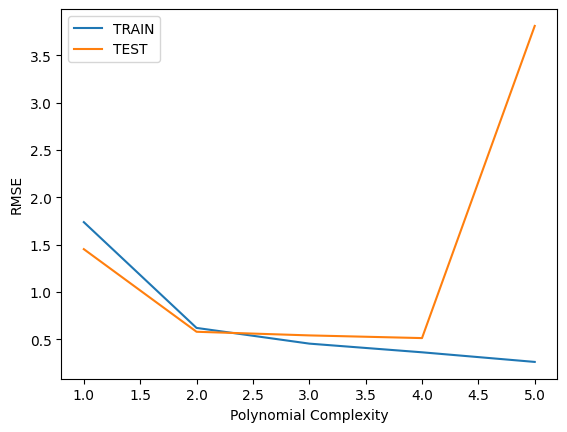

In [ ]:
plt.plot(range(1,6),train_rmse_er[:5],label='TRAIN')
plt.plot(range(1,6),test_rmse_er[:5],label='TEST')
plt.xlabel('Polynomial Complexity')
plt.ylabel('RMSE')
plt.legend()
plt.show()

# Final Model Choice

In [ ]:
final_polyconv = PolynomialFeatures(degree=3,include_bias=False)

In [ ]:
final_model = LinearRegression()

In [ ]:
final_model.fit(final_polyconv.fit_transform(X),y)

LinearRegression()

In [ ]:
from joblib import dump, load
dump(final_model,'/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/13_Linear_regression/sales_poly_model.joblib')
dump(final_polyconv,'/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/13_Linear_regression/sales_polyconv.joblib')

['/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/13_Linear_regression/sales_polyconv.joblib']

#Prediction

In [ ]:
ad_campaign = [[122,53,43],[122,53,9871],[222,153,0]]

In [ ]:
loaded_poly = load('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/13_Linear_regression/sales_polyconv.joblib')

In [ ]:
loaded_model = load('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/13_Linear_regression/sales_poly_model.joblib')

In [ ]:
ad_campaign_poly = loaded_poly.transform(ad_campaign)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [ ]:
loaded_model.predict(ad_campaign_poly)

array([ 1.90988371e+01, -2.18229431e+06,  6.20479489e+01])